# Prac 03. Part 1

For this homework you are going to implement the **unsharp masking** filter (USM). It is a technique to improve the sharpness of an image by combining the image with its blurred (unsharp) version. See the Wikipedia [page](https://en.wikipedia.org/wiki/Unsharp_masking) for more details.

### Unsharp Masking (USP)
The USM technique consists of the following steps:
* Load the image you will be working with.
* Create a blurred (unsharp) version of the original image.
* Add the unsharp image (with a certain **weight**) to the original.

To sum it up, the USM performs the following operation:

`sharpened = original + (original − unsharp) × amount`

Even though we provide you an image to work with, you are welcome to use your own images :-)

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

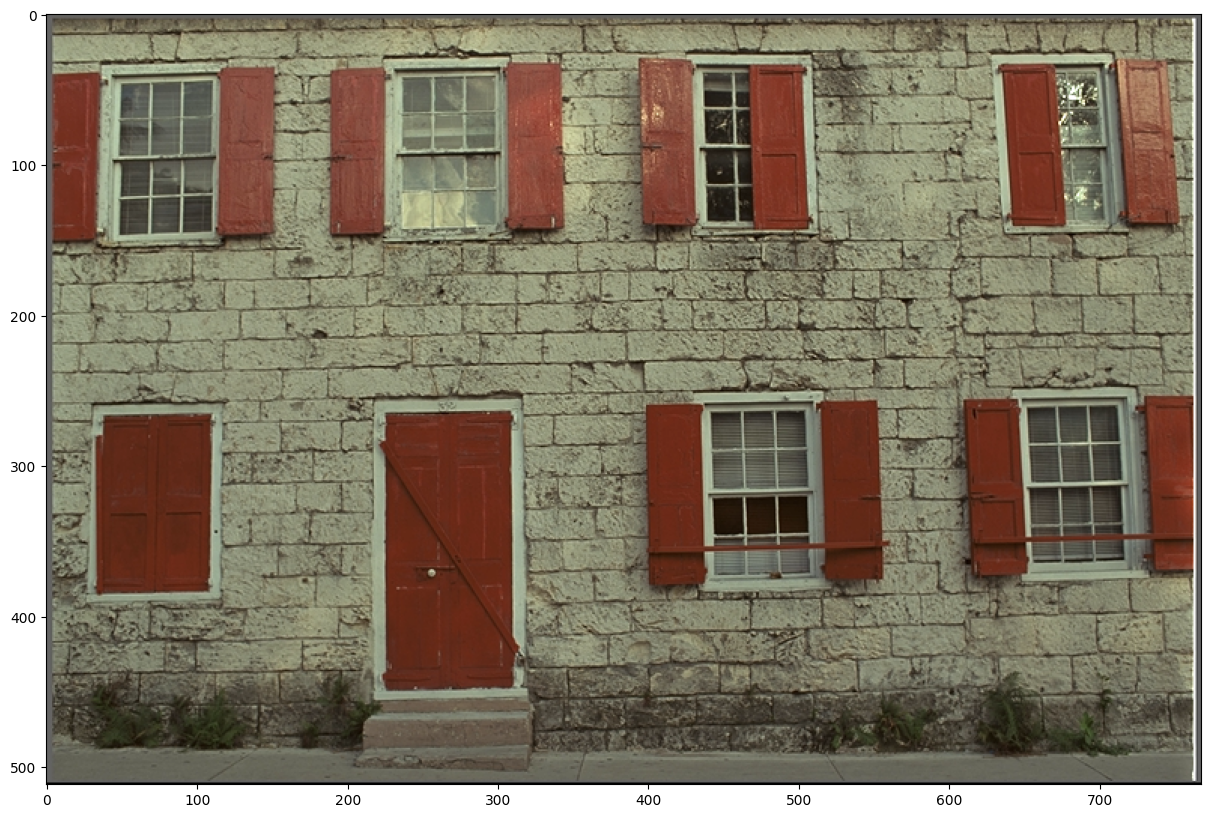

In [ ]:
img = cv2.imread('kodim01.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

In [ ]:
# Create a blurred (unsharp) version of the original image (you can use Gaussian blurring)
unsharp = cv2.GaussianBlur(img, (11, 11), sigmaX=0)

In [ ]:
# Create the difference image (original − unsharp)
# Note: Remember that you are working with uint8 data types. Any addition or substractions
# might result in overflow or underflow, respectively. You can prevent this by casting the images to float.
img_float = img.astype(np.float32)
unsharp_float = unsharp.astype(np.float32)
diff = img_float - unsharp_float

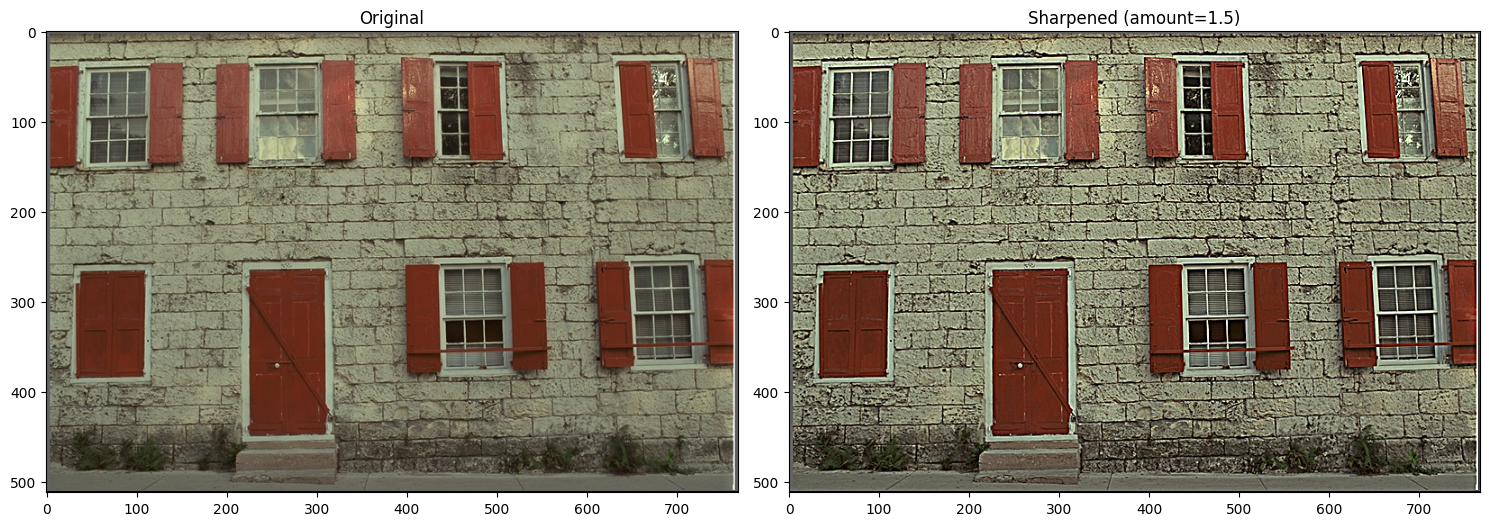

In [ ]:
# Apply USM to get the resulting image using `sharpened = original + (original − unsharp) × amount`
# Note: Again, take care of underflows/overflows if necessary.
sharpened_float = img_float + diff * 1.5
sharpened = np.clip(sharpened_float, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2)
axes[0].imshow(img)
axes[0].set_title('Original')
axes[1].imshow(sharpened)
axes[1].set_title(f'Sharpened (amount={1.5})')
plt.tight_layout()
plt.show()

### Questions
* What is a good (reasonable) value for the `amount` parameter?
 * What happens if it is too small?
 * What happens if it is too large?




- **Reasonable value** of `amount` is typically chosen in the range 0.5–2.0. Values of 1.0–1.5 provide noticeable sharpening without introducing artifacts.
- **If too small** the result looks almost identical to the original, the sharpening effect is imperceptible.
- **If too large** strong artifacts appear — halos around edges, excessive contrast, and clipped (over- or underexposed) pixels due to value overflow.